In [1]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import random
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage import feature 
from torchvision import datasets, models, transforms
import pickle
import os

In [2]:
def segment_image(image, label):
    # gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
    #                             cv2.THRESH_BINARY, 45, 2)
    # # mask = cv2.erode(mask, None, iterations=2)
    # mask = cv2.dilate(mask, None, iterations=2)
    # mask = cv2.erode(mask, None, iterations=1)
    # mask = cv2.bitwise_not(mask)
    # result = cv2.bitwise_and(image, image, mask=mask)
    
    nmax = 1 #New maximum
    nmin = 0 #New minimum
    hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    out = cv2.normalize(hsv_img,None,alpha = nmin,beta = nmax,norm_type = cv2.NORM_MINMAX)
    mask = np.zeros(image.shape, np.float32)
    mask = cv2.inRange(out[:, :, 1], 0, 0.08)
    mask = cv2.bitwise_not(mask)
    mask = cv2.dilate(mask, None, iterations=2)
    mask = cv2.erode(mask, None, iterations=2)
    
    # print(out[:,:,1].max(), out[:,:,1].min())
    
    fig = plt.figure(figsize=(9, 6))

    plt.axis('off') 
    plt.title("Saturation Channel")
    plt.imshow(out[:, :, 1], cmap='gray', vmin=0, vmax=1)
    
    fig = plt.figure(figsize=(9, 6))
    
    no_whiteBG = cv2.bitwise_and(image, image, mask=mask)
    
    plt.axis('off') 
    plt.title("No White Background")
    plt.imshow(cv2.cvtColor(no_whiteBG, cv2.COLOR_BGR2RGB))
    
    # bgModel = np.zeros((1, 65), np.float64)
    # fgModel = np.zeros((1, 65), np.float64)

    # # Rectangle awal perkiraan daun
    # rect = (1, 1, 225, 225)
    # cv2.grabCut(image, mask, rect, bgModel, fgModel, 8, cv2.GC_INIT_WITH_RECT)

    # mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    
    # fig = plt.figure(figsize=(9, 6))

    # plt.axis('off') 
    # plt.title(label)
    # plt.imshow(cv2.cvtColor(mask2*255, cv2.COLOR_BGR2RGB))
    
    # lower_yellow = np.array([ 15, 0, 56])  # Adjust as needed
    # upper_yellow = np.array([32, 255, 255])  # Adjust as
    
    # lower_chocolate = np.array([0, 10, 0])
    # upper_chocolate = np.array([15, 255, 255])
    
    # yellow_mask = cv2.inRange(hsv_img, lower_yellow, upper_yellow)
    # dark_chocolate_mask = cv2.inRange(hsv_img, lower_chocolate, upper_chocolate)
    
    # mask3 = cv2.bitwise_or(yellow_mask, dark_chocolate_mask)
    # mask3 = cv2.bitwise_and(mask3, mask3, mask=mask2)
    
    # print(mask3.max(), image.shape)
    
    # fig = plt.figure(figsize=(9, 6))

    # plt.axis('off') 
    # plt.title(label)
    # plt.imshow(cv2.cvtColor(mask3, cv2.COLOR_BGR2RGB))
    
    # mask = cv2.erode(mask, None, iterations=2)
    # mask = cv2.dilate(mask, None, iterations=2)
    # mask = cv2.bitwise_not(mask)
    # result = cv2.bitwise_and(image, image, mask=mask3)
    
    # return result
    
    return mask

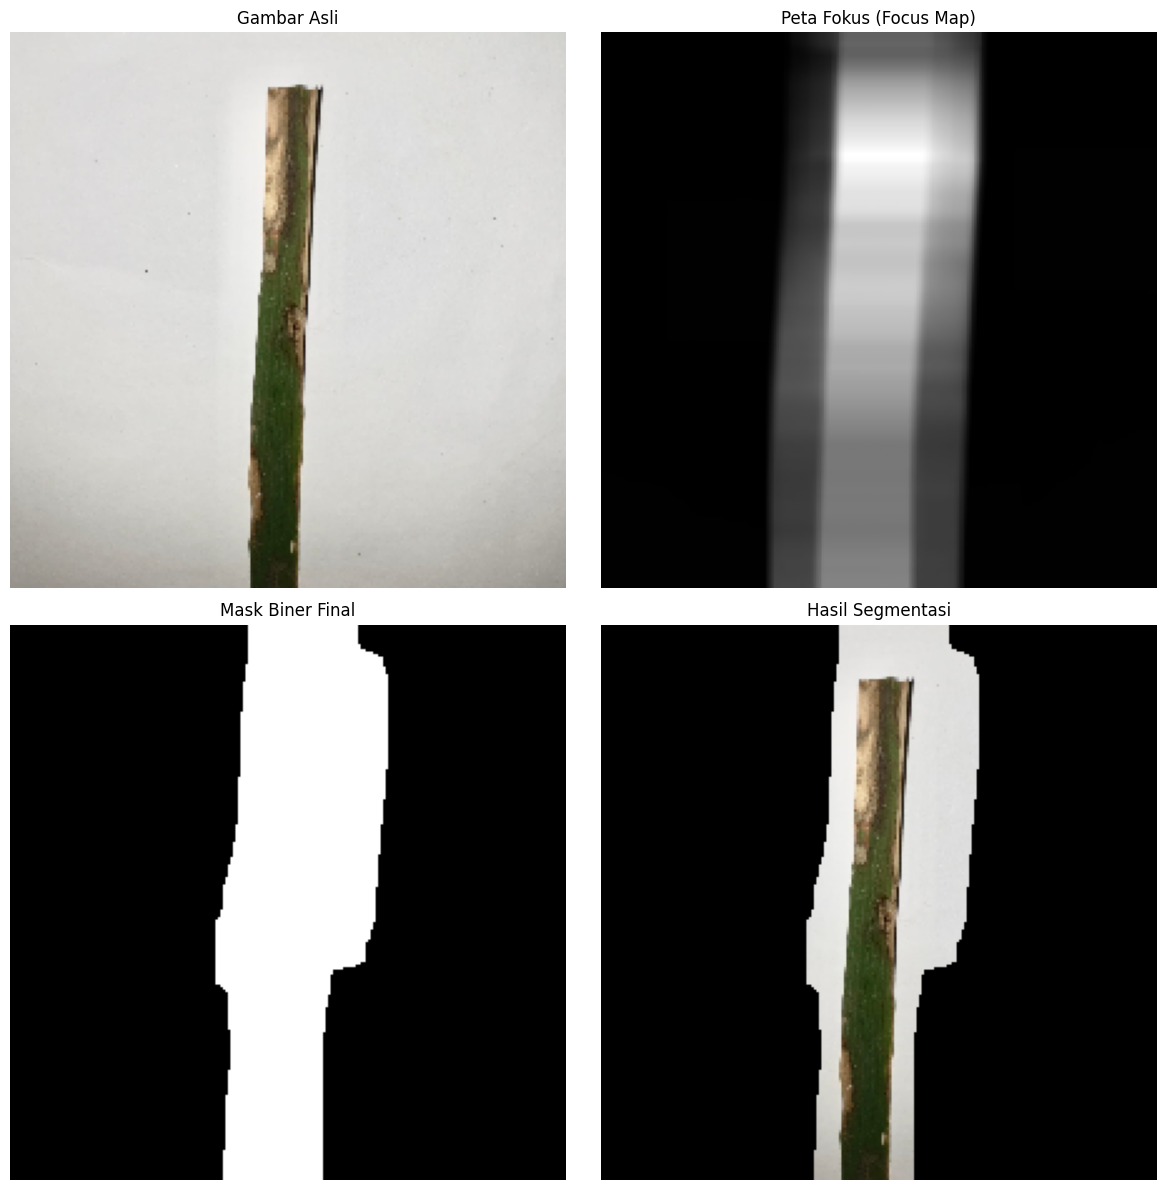

In [48]:
def segment_by_focus(image_path, window_size=15, laplacian_ksize=3):
    """
    Melakukan segmentasi gambar berdasarkan fokus menggunakan Varian Laplacian.
    
    :param image_path: Path ke file gambar
    :param window_size: Ukuran 'window' untuk menghitung variansi lokal. 
                        Harus ganjil.
    :param laplacian_ksize: Ukuran kernel untuk filter Laplacian. Harus ganjil.
    :return: Gambar asli, mask biner, dan gambar yang tersegmentasi.
    """
    
    # --- Langkah 1: Muat Gambar dan Ubah ke Grayscale ---
    img_color = cv2.resize(cv2.imread(image_path), (222, 222))
    if img_color is None:
        print(f"Error: Tidak dapat memuat gambar dari {image_path}")
        return None, None, None
        
    # Ubah ke grayscale untuk pemrosesan
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    
    # --- Langkah 2: Hitung Laplacian ---
    # Kita menggunakan cv2.CV_64F (float 64-bit) untuk menghindari kehilangan data (overflow)
    # karena Laplacian bisa menghasilkan nilai negatif.
    laplacian = cv2.Laplacian(img_gray, cv2.CV_64F, ksize=laplacian_ksize)
    
    
    # --- Langkah 3: Hitung Peta Variansi (Focus Map) ---
    # Ini adalah inti dari metode ini.
    # Rumus Variansi: Var(X) = E[X^2] - (E[X])^2
    # E[X]   = rata-rata (bisa didapat dengan blurring)
    # E[X^2] = rata-rata dari kuadrat (bisa didapat dengan blurring pada X^2)

    # Hitung X^2 (kuadrat dari laplacian)
    laplacian_sq = laplacian**2
    
    # Hitung E[X] (rata-rata laplacian) menggunakan blur
    mean = cv2.blur(laplacian, (window_size, window_size))
    
    # Hitung E[X^2] (rata-rata dari laplacian kuadrat) menggunakan blur
    mean_sq = cv2.blur(laplacian_sq, (window_size, window_size))
    
    # Hitung variansi: Var = E[X^2] - (E[X])^2
    variance_map = mean_sq - mean**2
    
    # --- Langkah 4: Normalisasi dan Thresholding ---
    
    # Normalisasi 'focus map' ke rentang 0-255 agar bisa di-threshold
    variance_map_normalized = cv2.normalize(variance_map, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    
    # Gunakan Thresholding Otsu untuk secara OTOMATIS menemukan nilai ambang batas
    # Ini memisahkan area fokus (nilai variansi tinggi) dari area buram (nilai rendah)
    _, binary_mask = cv2.threshold(variance_map_normalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    

    # --- Langkah 5: Pembersihan Mask (Morphological Operations) ---
    # Mask awal mungkin 'berlubang' atau memiliki 'bintik-bintik' noise.
    
    # Buat kernel (elemen struktural)
    morph_kernel_size = 5
    kernel = np.ones((morph_kernel_size, morph_kernel_size), np.uint8)
    
    # 1. Closing (Menutup lubang-lubang kecil DI DALAM objek fokus)
    # Ini adalah Dilation diikuti Erotion
    mask_cleaned = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    
    
    # 2. Opening (Menghilangkan bintik-bintik noise DI LUAR objek)
    # Ini adalah Erotion diikuti Dilation
    mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_OPEN, kernel, iterations=2)

    # --- Langkah 6: (Opsional tapi Direkomendasikan) Ambil Kontur Terbesar ---
    # Asumsinya, daun Anda adalah objek fokus terbesar di gambar.
    
    contours, _ = cv2.findContours(mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        # Temukan kontur dengan area terbesar
        largest_contour = max(contours, key=cv2.contourArea)
        
        # Buat mask baru yang hanya berisi kontur terbesar
        final_mask = np.zeros_like(mask_cleaned)
        cv2.drawContours(final_mask, [largest_contour], -1, (255), thickness=cv2.FILLED)
    else:
        final_mask = mask_cleaned # Gunakan mask sebelumnya jika tidak ada kontur

    # --- Langkah 7: Terapkan Mask ke Gambar Asli ---
    segmented_result = cv2.bitwise_and(img_color, img_color, mask=final_mask)

    return img_color, variance_map_normalized, final_mask, segmented_result

# --- Cara Menjalankan Kode Ini ---

# Ganti dengan path ke gambar Anda
# image_path = 'datasets/Malba_test_images/normal/IMG_5368.jpg'
# image_path = 'datasets/rice_leaves_disease/brown_spot/Brown_spot  (44).jpg'
# image_path = 'datasets/leaf-rice-disease-indonesia/bacterial_leaf_blight/IMG_0965.jpg'
image_path = 'datasets/leaf-rice-disease-indonesia/bacterial_leaf_blight/IMG_1072.jpg'

# Coba ubah nilai-nilai ini
WINDOW_SIZE = 57       # Coba nilai antara 11, 21, 31. Lebih besar = lebih 'halus'
LAPLACIAN_KSIZE = 5    # Coba 3 atau 5. Lebih besar = lebih sensitif

# Jalankan fungsi
original_img, focus_map, mask, segmented_img = segment_by_focus(
    image_path, 
    window_size=WINDOW_SIZE, 
    laplacian_ksize=LAPLACIAN_KSIZE
)

# Tampilkan hasil menggunakan Matplotlib
if original_img is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # Ubah BGR (OpenCV) ke RGB (Matplotlib)
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    segmented_img_rgb = cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB)
    
    axes[0, 0].imshow(original_img_rgb)
    axes[0, 0].set_title('Gambar Asli')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(focus_map, cmap='gray')
    axes[0, 1].set_title('Peta Fokus (Focus Map)')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(mask, cmap='gray')
    axes[1, 0].set_title('Mask Biner Final')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(segmented_img_rgb)
    axes[1, 1].set_title('Hasil Segmentasi')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

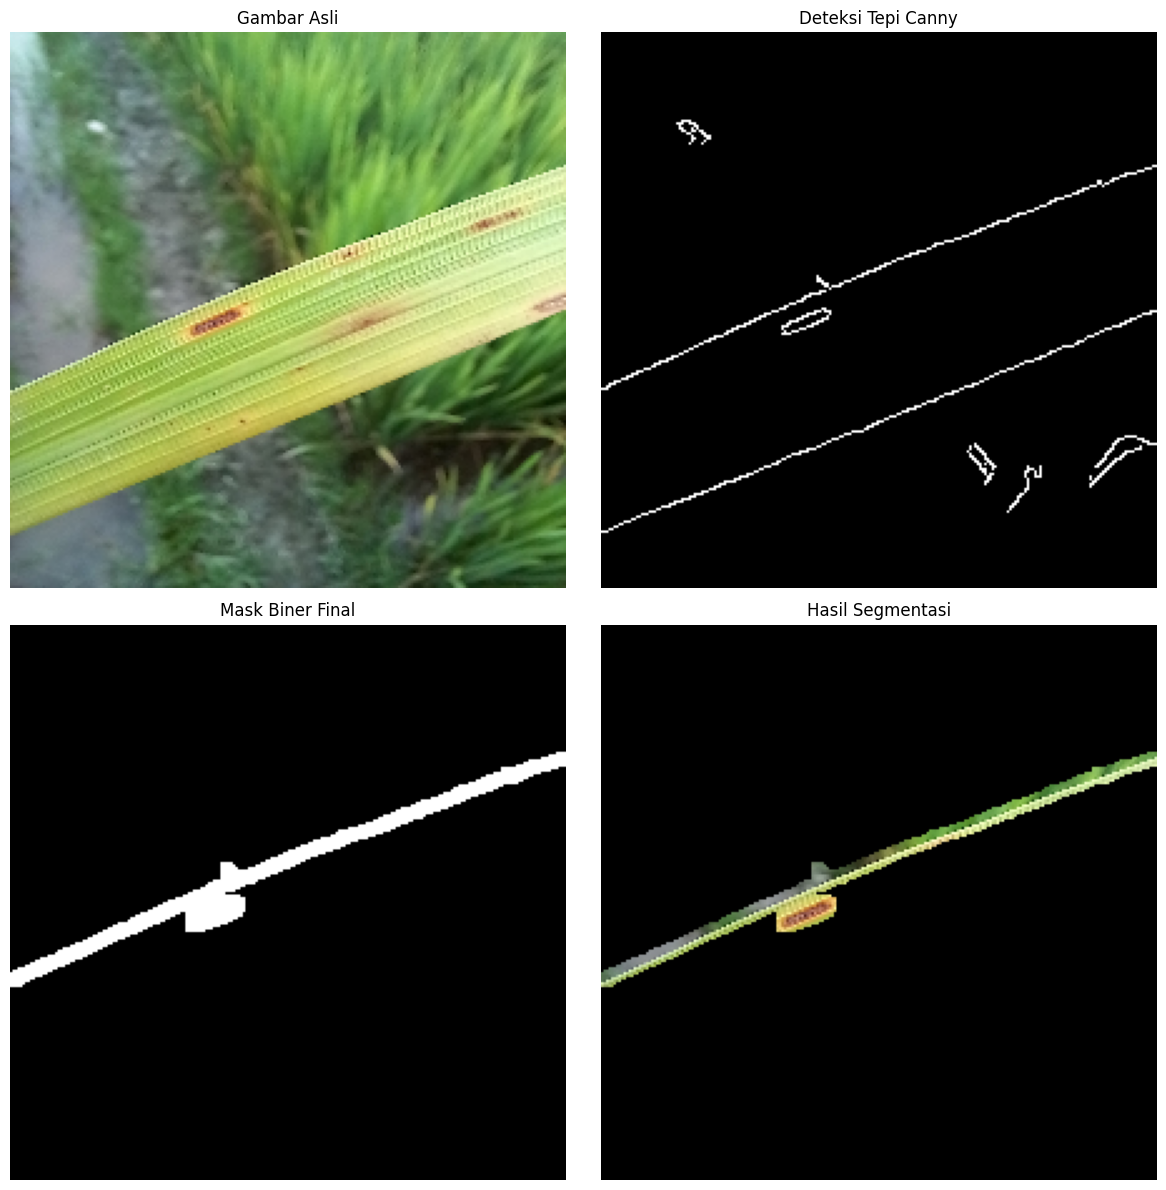

In [34]:
def segment_by_edges(image_path, blur_ksize=7, canny_thresh1=50, canny_thresh2=150):
    """
    Melakukan segmentasi gambar berdasarkan deteksi tepi (Canny) dan
    pencarian kontur (Bentuk).
    
    :param image_path: Path ke file gambar
    :param blur_ksize: Ukuran kernel untuk Gaussian Blur (mengurangi noise). Harus ganjil.
    :param canny_thresh1: Threshold bawah untuk Canny.
    :param canny_thresh2: Threshold atas untuk Canny.
    :return: Gambar asli, peta tepi Canny, mask biner, dan gambar tersegmentasi.
    """
    
    # --- Langkah 1: Muat Gambar dan Preprocessing ---
    img_color = cv2.resize(cv2.imread(image_path), (222, 222))
    if img_color is None:
        print(f"Error: Tidak dapat memuat gambar dari {image_path}")
        return None, None, None, None
        
    # Ubah ke grayscale
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
    
    # Terapkan blur untuk mengurangi noise. Ini SANGAT PENTING untuk Canny.
    img_blur = cv2.GaussianBlur(img_gray, (blur_ksize, blur_ksize), 0)
    
    # --- Langkah 2: Deteksi Tepi dengan Canny ---
    # Canny mendeteksi tepi yang kuat di antara dua nilai threshold.
    canny_edges = cv2.Canny(img_blur, canny_thresh1, canny_thresh2)
    
    
    # --- Langkah 3: (Opsional) Pertebal Tepi ---
    # Terkadang tepi Canny terlalu tipis. Kita bisa menebalkannya (dilate)
    # agar `findContours` dapat bekerja lebih baik dan menutup celah kecil.
    kernel = np.ones((5, 5), np.uint8)
    canny_dilated = cv2.dilate(canny_edges, kernel, iterations=1)

    # --- Langkah 4: Temukan Kontur (Deteksi Bentuk) ---
    # cv2.RETR_EXTERNAL: Hanya mengambil kontur paling luar (induk), 
    #                    mengabaikan kontur di dalam kontur (misal, lubang).
    # cv2.CHAIN_APPROX_SIMPLE: Menyimpan kontur secara efisien.
    contours, _ = cv2.findContours(canny_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        print("Tidak ada kontur yang ditemukan. Coba sesuaikan parameter Canny.")
        # Kembalikan mask kosong jika tidak ada kontur
        empty_mask = np.zeros_like(img_gray)
        segmented_empty = cv2.bitwise_and(img_color, img_color, mask=empty_mask)
        return img_color, canny_edges, empty_mask, segmented_empty

    # --- Langkah 5: Filter Kontur (Asumsi Daun = Area Terbesar) ---
    # Ini adalah logika "deteksi" utamanya.
    # Kita asumsikan daun yang kita inginkan adalah objek terbesar di gambar.
    largest_contour = max(contours, key=cv2.contourArea)
    
    # --- Langkah 6: Buat Mask Biner dari Kontur Terpilih ---
    # Buat gambar hitam kosong seukuran gambar asli
    final_mask = np.zeros_like(img_gray)
    
    # Gambar kontur terbesar yang kita temukan ke mask dengan warna putih (255)
    # 'thickness=cv2.FILLED' berarti kita mengisi seluruh bentuk, 
    # bukan hanya garis tepinya.
    cv2.drawContours(final_mask, [largest_contour], -1, (255), thickness=cv2.FILLED)
    

    # --- Langkah 7: Terapkan Mask ke Gambar Asli ---
    segmented_result = cv2.bitwise_and(img_color, img_color, mask=final_mask)

    return img_color, canny_edges, final_mask, segmented_result

# --- Cara Menjalankan Kode Ini ---

# Ganti dengan path ke gambar Anda
# image_path = 'datasets/Malba_test_images/normal/IMG_5368.jpg'
# image_path = 'datasets/Malba_test_images/normal/IMG_5334.jpg'
# image_path = 'datasets/local_dataset_no_duplicate/bacterial_leaf_blight/BACTERAILBLIGHT5_099.jpg'
image_path = 'datasets/rice_leaves_disease/brown_spot/Brown_spot  (44).jpg'
# image_path = 'datasets/paddy-disease-classification/train_images/bacterial_leaf_blight/102617.jpg'

# --- PARAMETER PENTING UNTUK DI-TUNE ---
BLUR_KSIZE = 7        # Coba: 5, 7, 11. Lebih besar = lebih buram, noise berkurang.
CANNY_THRESH_1 = 50   # Coba rendahkan jika tidak ada tepi terdeteksi.
CANNY_THRESH_2 = 210  # Coba naikkan jika terlalu banyak noise terdeteksi.
# ----------------------------------------

# Jalankan fungsi
original_img, canny_map, mask, segmented_img = segment_by_edges(
    image_path, 
    blur_ksize=BLUR_KSIZE, 
    canny_thresh1=CANNY_THRESH_1,
    canny_thresh2=CANNY_THRESH_2
)

# Tampilkan hasil menggunakan Matplotlib
if original_img is not None:
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # Ubah BGR (OpenCV) ke RGB (Matplotlib)
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    segmented_img_rgb = cv2.cvtColor(segmented_img, cv2.COLOR_BGR2RGB)
    
    axes[0, 0].imshow(original_img_rgb)
    axes[0, 0].set_title('Gambar Asli')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(canny_map, cmap='gray')
    axes[0, 1].set_title('Deteksi Tepi Canny')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(mask, cmap='gray')
    axes[1, 0].set_title('Mask Biner Final')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(segmented_img_rgb)
    axes[1, 1].set_title('Hasil Segmentasi')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

Text(0.5, 1.0, 'B Channel')

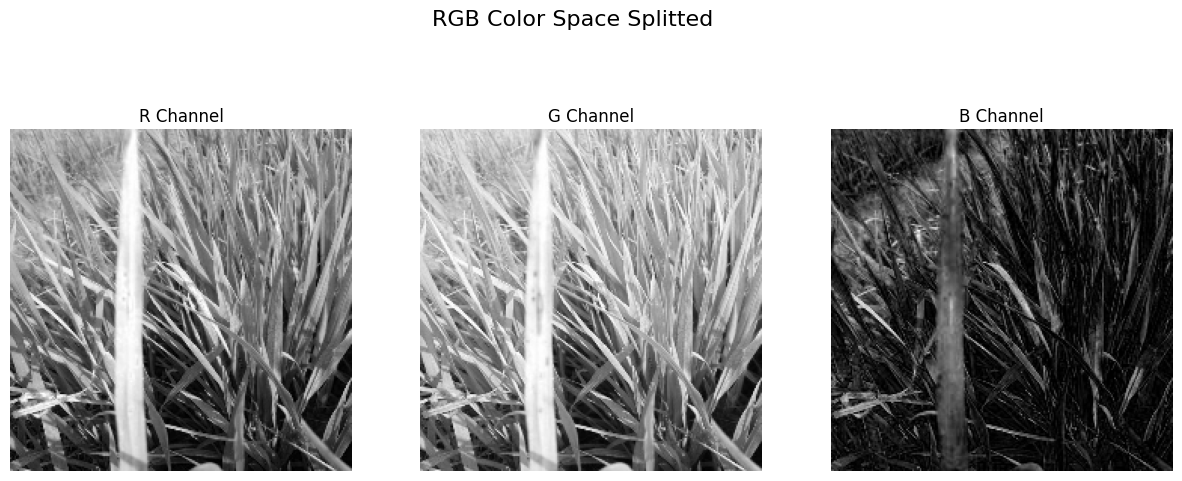

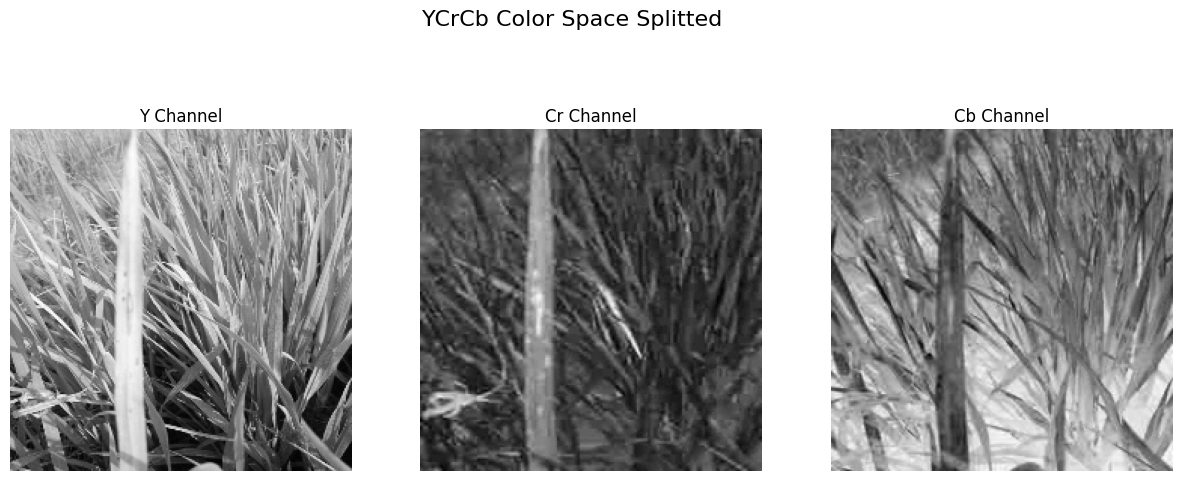

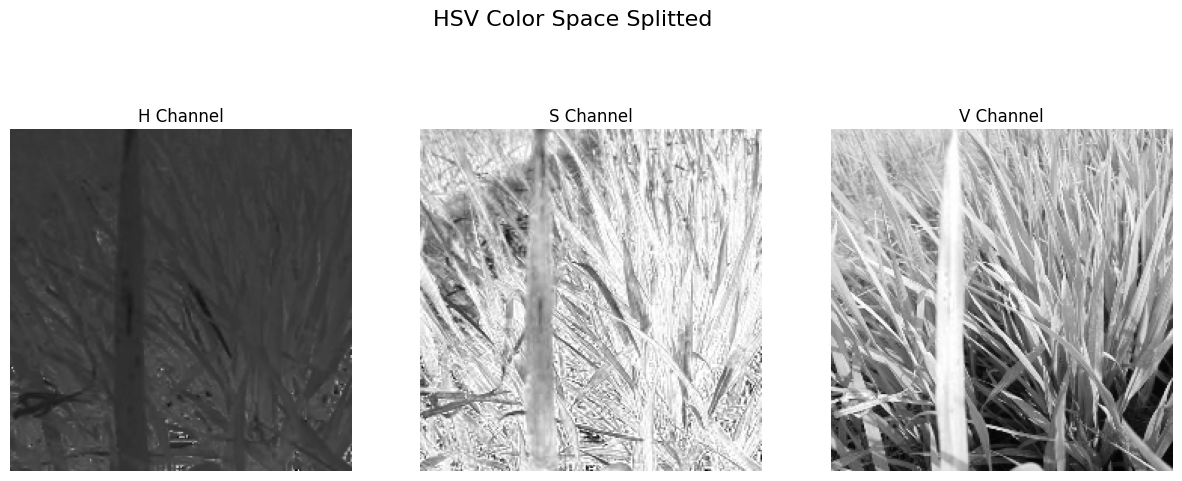

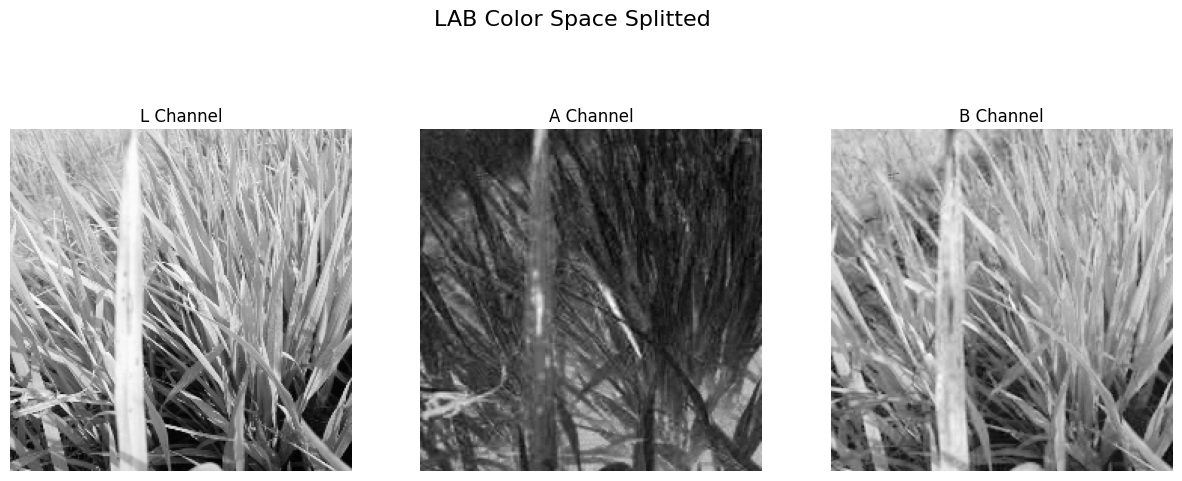

In [13]:
IMG_SIZE = (227, 227)
label = 'normal'
img = cv2.resize(cv2.imread('datasets/paddy-disease-classification/train_images/bacterial_leaf_blight/102617.jpg'), IMG_SIZE)

fig = plt.figure(figsize=(15, 6))

fig.suptitle('RGB Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("R Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("G Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("B Channel")

fig = plt.figure(figsize=(15, 6))

fig.suptitle('YCrCb Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("Y Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("Cr Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("Cb Channel")

fig = plt.figure(figsize=(15, 6))

fig.suptitle('HSV Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("H Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("S Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("V Channel")

fig = plt.figure(figsize=(15, 6))

fig.suptitle('LAB Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("L Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("A Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("B Channel")

(227, 227, 3)


Text(0.5, 1.0, 'brown_spot')

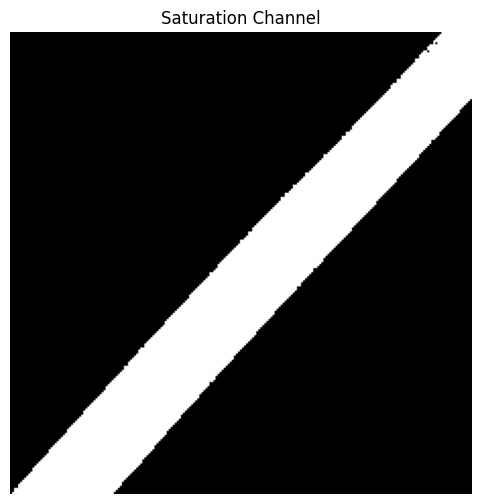

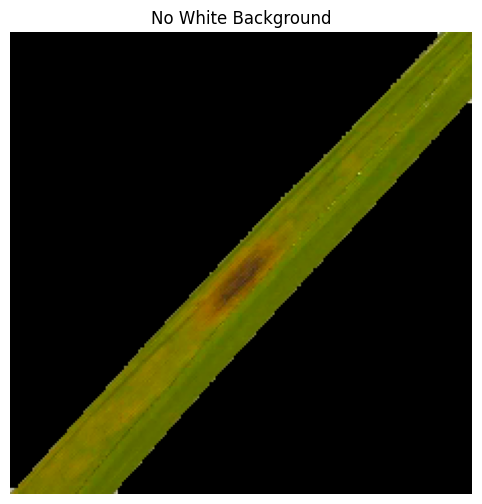

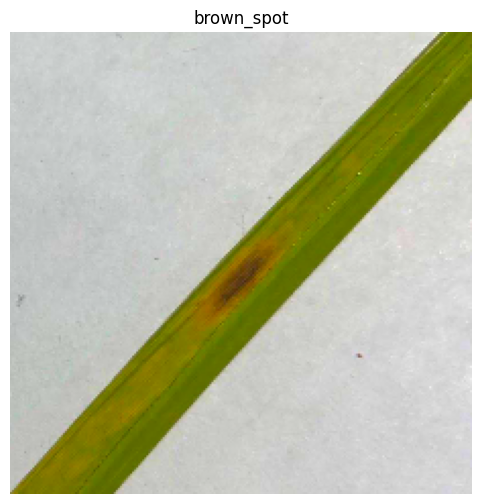

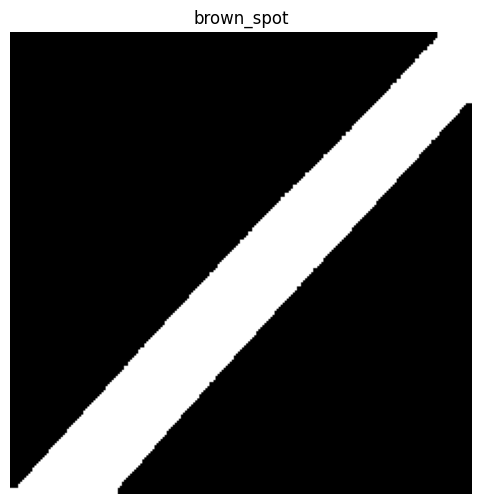

In [ ]:
print(img.shape)
segmented_image = segment_image(img, label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(segmented_image, cmap='gray')
plt.axis('off') 
plt.title(label)

(227, 227, 3)


Text(0.5, 1.0, 'brown_spot')

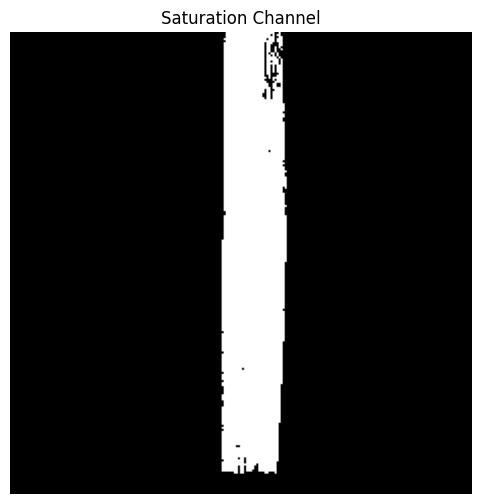

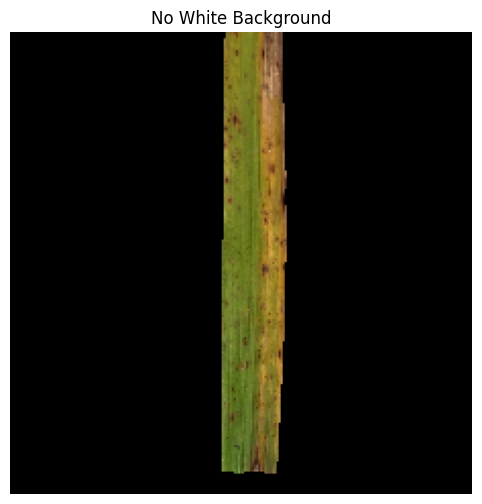

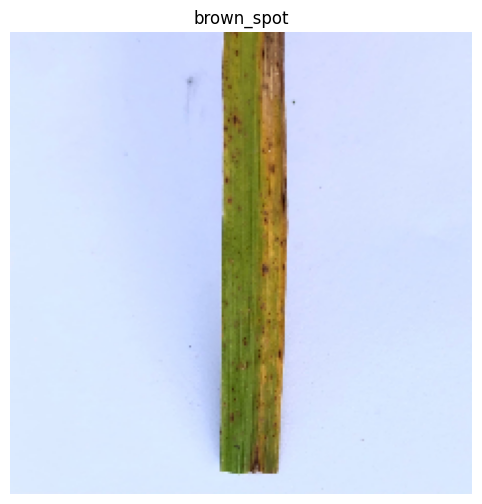

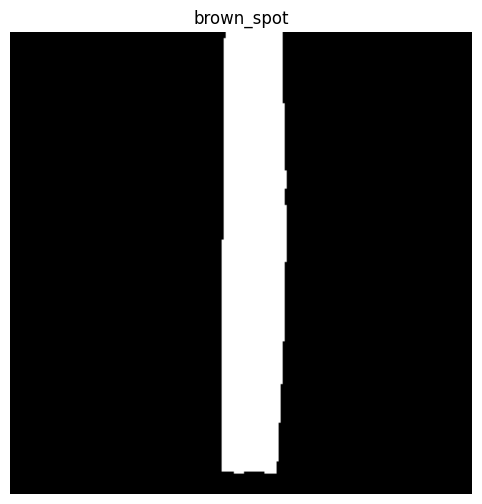

In [21]:
IMG_SIZE = (227, 227)
label = 'brown_spot'
img = cv2.resize(cv2.imread('datasets/leaf-rice-disease-indonesia/tungro/IMG_0872.jpg'), IMG_SIZE)
print(img.shape)
segment_image2 = segment_image(img, label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(segment_image2, cmap='gray')
plt.axis('off') 
plt.title(label)